# Comparison: Single-Stage (0403) vs Two-Stage (0407)

Re-run evaluation on both pipelines with parallel citation dedup (keep most severe) and compare completeness, quality, and cost.

In [1]:
import sys
sys.path.insert(0, '../citator-pipeline')

import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

from utils.eval_utils import evaluate_example

## Run Evaluation on Both Pipelines

0403: Single-Stage (Sonnet + Kimi re-eval)
Instruction Length (char):  20646

=== Overall Statistics ===
Total number of citing cases:  9
Total number of input tokens:  232884
Total number of output tokens:  78414
Total latency (ms):  822663

=== Evaluation Statistics ===
Using post-processed results: ../experiments_04032026/data/output/final_results.csv
Number of results in both model & expert labels:  289
Number of results with both model and expert treatment:  268
Number of results from model not in expert labels:  8
Number of expert labels missed by model:  3

=== Evaluation Metrics on Matched Results with Treatment ===

=== Overall Severity ===
              precision    recall  f1-score   support

     Caution       0.64      0.33      0.44        21
     Neutral       0.56      0.83      0.67        23
        Stop       0.92      1.00      0.96        12
     Warning       0.00      0.00      0.00         2

    accuracy                           0.66        58
   macro avg    

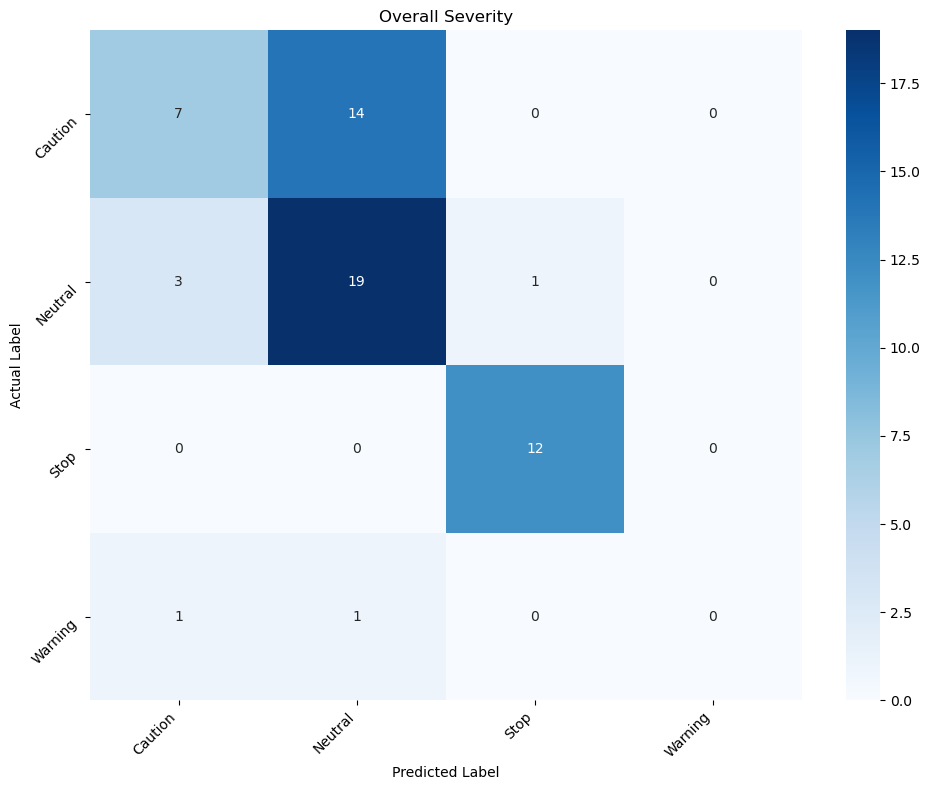


=== Overall Direction ===
                   precision    recall  f1-score   support

 Citing Reference       0.69      0.92      0.79        26
   Direct History       1.00      1.00      1.00         5
Related Reference       0.89      0.59      0.71        27

         accuracy                           0.78        58
        macro avg       0.86      0.84      0.83        58
     weighted avg       0.81      0.78      0.77        58


--- FP, FN, TP by class (Overall Direction) ---
      Class Label  FP  FN  TP
 Citing Reference  11   2  24
   Direct History   0   0   5
Related Reference   2  11  16

--- Confusion Matrix (Overall Direction) ---


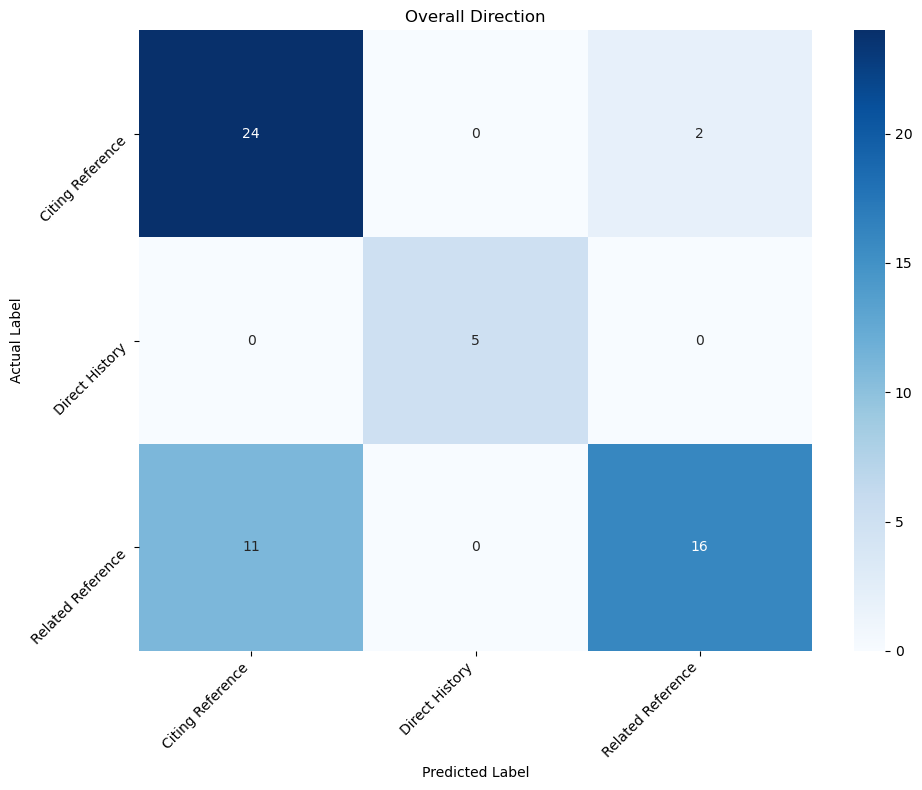


=== Treatment Evaluation ===
                                        precision    recall  f1-score   support

             Affirmed as recognized by       1.00      1.00      1.00         2
                           Affirmed by       1.00      1.00      1.00         1
         Cert. denied as recognized by       0.71      0.36      0.48        14
                              Cited by       0.08      0.33      0.13         6
                        Disapproved by       0.00      0.00      0.00         1
        Distinguished as recognized by       0.00      0.00      0.00         3
                      Distinguished by       0.64      0.39      0.48        18
                            Limited by       0.00      0.00      0.00         1
            Overruled as recognized by       0.88      1.00      0.93         7
Reversed and remanded as recognized by       0.00      0.00      0.00         1
              Reversed and remanded by       1.00      0.50      0.67         2
         

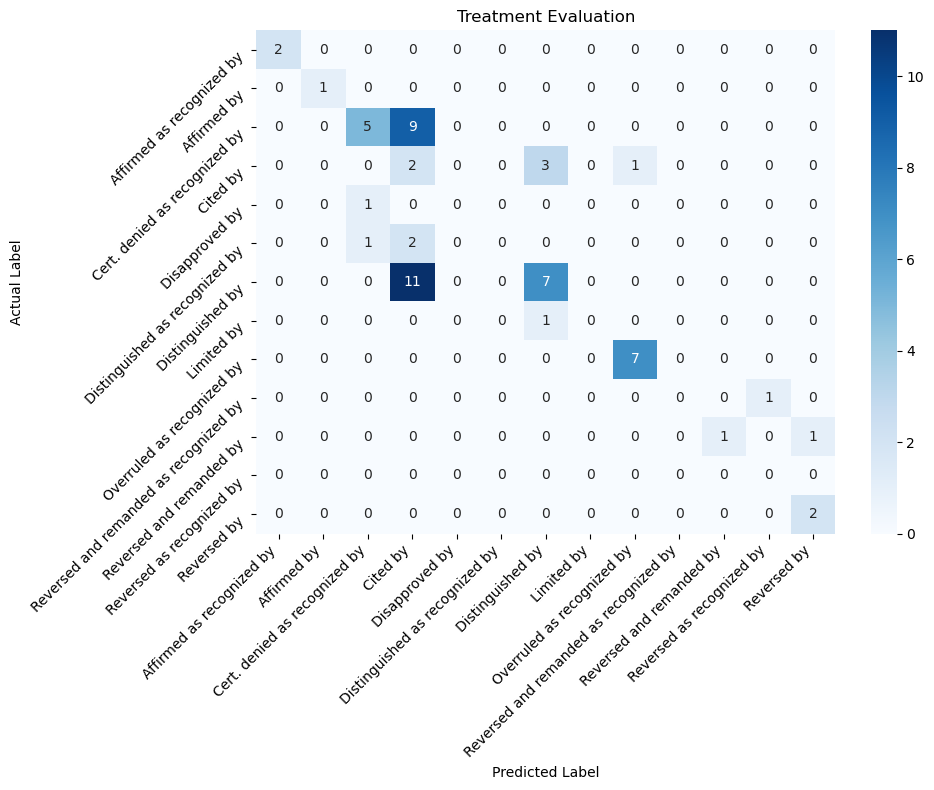

In [2]:
labels_path = '../data/benchmark_original/0410.csv'

print('=' * 80)
print('0403: Single-Stage (Sonnet + Kimi re-eval)')
print('=' * 80)
evaluate_example(
    output_dir='../experiments_04032026/data/output',
    eval_dir='../experiments_04032026/data/eval',
    labels_path=labels_path,
)

0407: Two-Stage (Haiku + Kimi classification)
Instruction Length (char):  20646

=== Overall Statistics ===
Total number of citing cases:  9
Total number of input tokens:  133292
Total number of output tokens:  19971
Total latency (ms):  114866

=== Evaluation Statistics ===
Using post-processed results: data/output/final_results.csv
Number of results in both model & expert labels:  288
Number of results with both model and expert treatment:  267
Number of results from model not in expert labels:  7
Number of expert labels missed by model:  4

=== Evaluation Metrics on Matched Results with Treatment ===

=== Overall Severity ===
              precision    recall  f1-score   support

     Caution       0.82      0.67      0.74        21
     Neutral       0.69      0.83      0.75        24
        Stop       0.92      1.00      0.96        11
     Warning       0.00      0.00      0.00         2

    accuracy                           0.78        58
   macro avg       0.61      0.62    

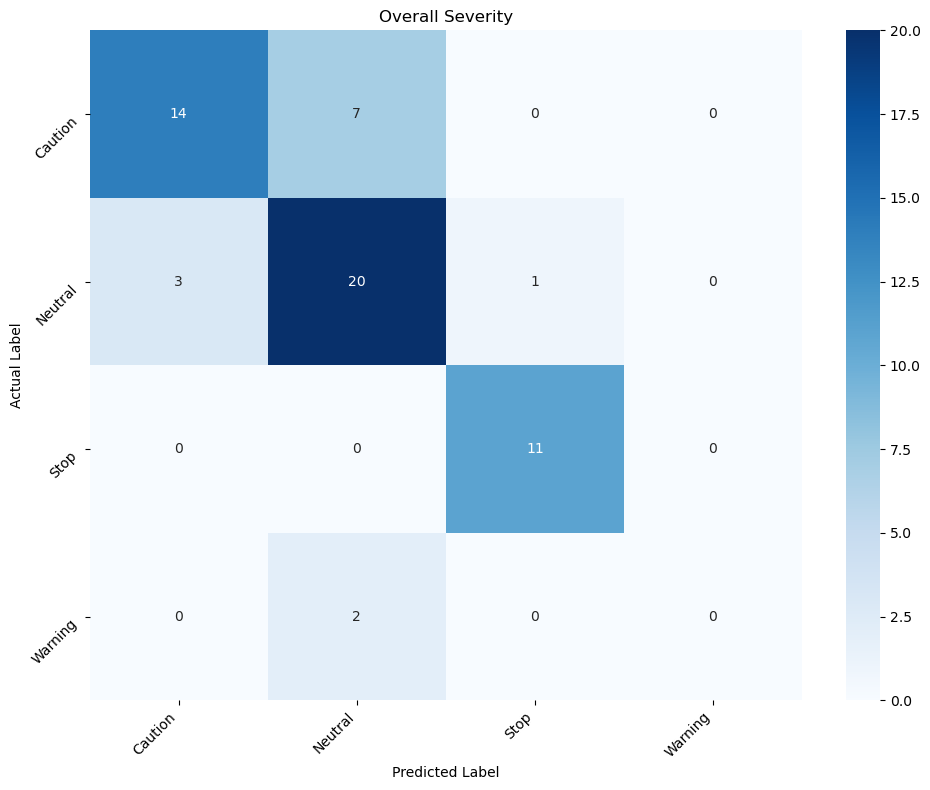


=== Overall Direction ===
                   precision    recall  f1-score   support

 Citing Reference       0.92      0.85      0.88        27
   Direct History       1.00      1.00      1.00         5
Related Reference       0.86      0.92      0.89        26

         accuracy                           0.90        58
        macro avg       0.93      0.92      0.92        58
     weighted avg       0.90      0.90      0.90        58


--- FP, FN, TP by class (Overall Direction) ---
      Class Label  FP  FN  TP
 Citing Reference   2   4  23
   Direct History   0   0   5
Related Reference   4   2  24

--- Confusion Matrix (Overall Direction) ---


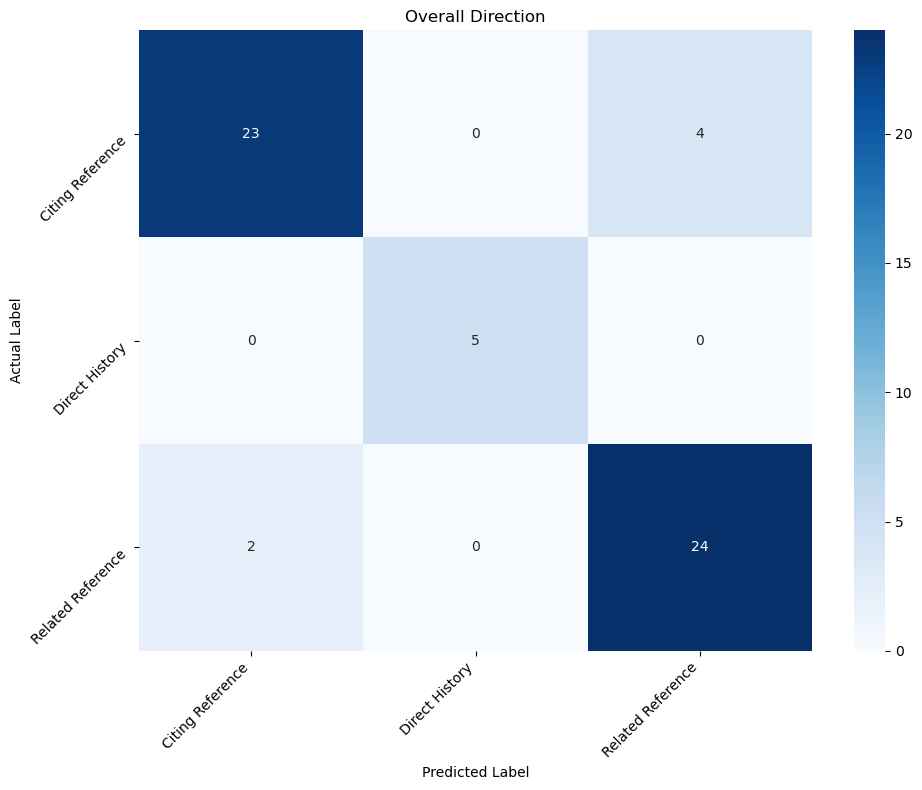


=== Treatment Evaluation ===
                                        precision    recall  f1-score   support

             Affirmed as recognized by       0.50      0.50      0.50         2
                           Affirmed by       1.00      1.00      1.00         1
         Cert. denied as recognized by       0.88      1.00      0.93        14
                              Cited by       0.20      0.29      0.24         7
                        Disapproved by       0.00      0.00      0.00         1
        Distinguished as recognized by       1.00      1.00      1.00         3
                      Distinguished by       0.79      0.61      0.69        18
                            Limited by       0.00      0.00      0.00         1
            Overruled as recognized by       0.83      0.83      0.83         6
                          Overruled by       0.00      0.00      0.00         0
Reversed and remanded as recognized by       1.00      1.00      1.00         1
         

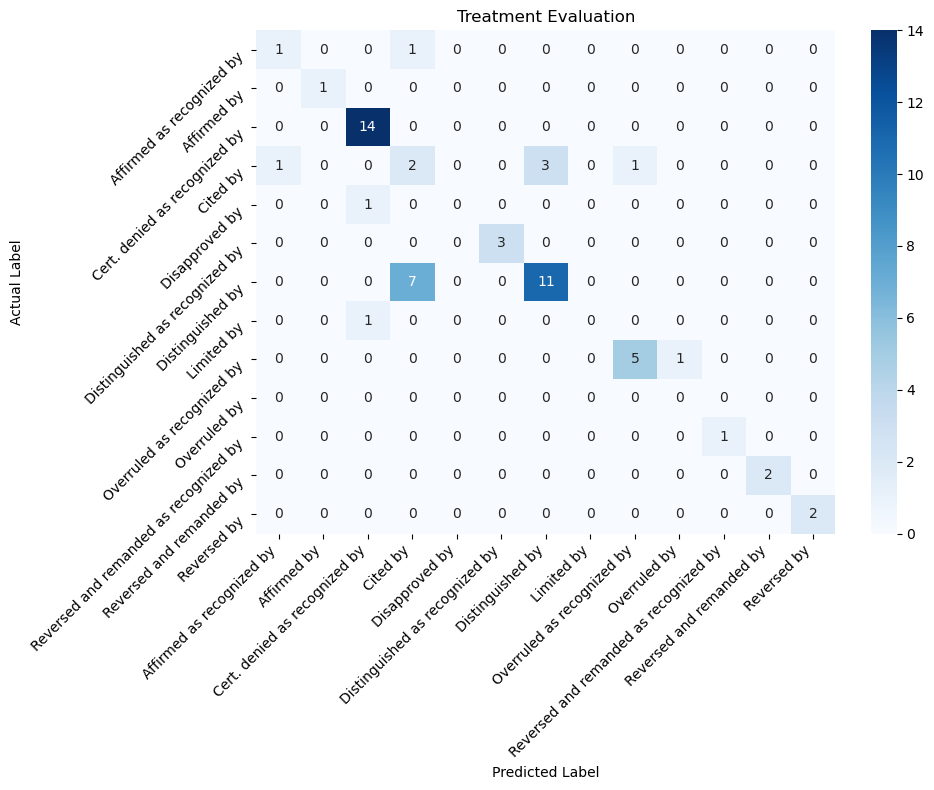

In [3]:
print('=' * 80)
print('0407: Two-Stage (Haiku + Kimi classification)')
print('=' * 80)
evaluate_example(
    output_dir='data/output',
    eval_dir='data/eval',
    labels_path=labels_path,
)

## Completeness Comparison

In [4]:
m03 = pd.read_csv('../experiments_04032026/data/eval/matched_results.csv')
m07 = pd.read_csv('data/eval/matched_results.csv')
mm03 = pd.read_csv('../experiments_04032026/data/eval/model_missed.csv')
mm07 = pd.read_csv('data/eval/model_missed.csv')
f03 = pd.read_csv('../experiments_04032026/data/output/final_results.csv')
f07 = pd.read_csv('data/output/final_results.csv')

completeness = pd.DataFrame([
    {'Pipeline': '0403 Sonnet + Kimi',
     'Final Predictions': len(f03),
     'Matched': len(m03),
     'Model Missed': len(mm03),
     'Match Rate': f'{len(m03)/(len(m03)+len(mm03))*100:.2f}%'},
    {'Pipeline': '0407 Haiku + Kimi',
     'Final Predictions': len(f07),
     'Matched': len(m07),
     'Model Missed': len(mm07),
     'Match Rate': f'{len(m07)/(len(m07)+len(mm07))*100:.2f}%'},
])
print(completeness.to_string(index=False))

          Pipeline  Final Predictions  Matched  Model Missed Match Rate
0403 Sonnet + Kimi                319      289             3     98.97%
 0407 Haiku + Kimi                336      288             4     98.63%


## Quality Comparison

In [5]:
def compute_metrics(eval_dir):
    """Compute F1 metrics with Cited by downsampling."""
    mwt = pd.read_csv(f'{eval_dir}/matched_with_treatment.csv')
    df = mwt.copy()
    cited_mask = (df['predicted_treatment'] == 'Cited by') & (df['label_treatment'] == 'Cited by')
    non_cited = df[~cited_mask]
    sampled = df[cited_mask].sample(frac=0.01, random_state=42)
    df = pd.concat([non_cited, sampled], ignore_index=True)

    results = {}
    for name, true_col, pred_col in [
        ('severity', 'label_severity', 'predicted_severity'),
        ('direction', 'label_direction', 'predicted_direction'),
        ('treatment', 'label_treatment', 'predicted_treatment'),
    ]:
        mask = df[true_col].notna() & df[pred_col].notna()
        sub = df[mask]
        results[f'{name}_macro'] = f1_score(sub[true_col], sub[pred_col], average='macro')
        results[f'{name}_weighted'] = f1_score(sub[true_col], sub[pred_col], average='weighted')
        results[f'{name}_n'] = len(sub)
    return results

m03_metrics = compute_metrics('../experiments_04032026/data/eval')
m07_metrics = compute_metrics('data/eval')

quality = pd.DataFrame([
    {'Metric': 'Severity (macro)', '0403': f'{m03_metrics["severity_macro"]:.2f}', '0407': f'{m07_metrics["severity_macro"]:.2f}'},
    {'Metric': 'Severity (weighted)', '0403': f'{m03_metrics["severity_weighted"]:.2f}', '0407': f'{m07_metrics["severity_weighted"]:.2f}'},
    {'Metric': 'Direction (macro)', '0403': f'{m03_metrics["direction_macro"]:.2f}', '0407': f'{m07_metrics["direction_macro"]:.2f}'},
    {'Metric': 'Direction (weighted)', '0403': f'{m03_metrics["direction_weighted"]:.2f}', '0407': f'{m07_metrics["direction_weighted"]:.2f}'},
    {'Metric': 'Treatment (macro)', '0403': f'{m03_metrics["treatment_macro"]:.2f}', '0407': f'{m07_metrics["treatment_macro"]:.2f}'},
    {'Metric': 'Treatment (weighted)', '0403': f'{m03_metrics["treatment_weighted"]:.2f}', '0407': f'{m07_metrics["treatment_weighted"]:.2f}'},
])
print(quality.to_string(index=False))

              Metric 0403 0407
    Severity (macro) 0.52 0.61
 Severity (weighted) 0.62 0.76
   Direction (macro) 0.83 0.92
Direction (weighted) 0.77 0.90
   Treatment (macro) 0.42 0.63
Treatment (weighted) 0.49 0.73


## Per-Treatment F1 Comparison

In [6]:
from sklearn.metrics import precision_recall_fscore_support

def per_treatment_f1(eval_dir):
    mwt = pd.read_csv(f'{eval_dir}/matched_with_treatment.csv')
    df = mwt.copy()
    cited_mask = (df['predicted_treatment'] == 'Cited by') & (df['label_treatment'] == 'Cited by')
    non_cited = df[~cited_mask]
    sampled = df[cited_mask].sample(frac=0.01, random_state=42)
    df = pd.concat([non_cited, sampled], ignore_index=True)

    labels = sorted(set(df['label_treatment'].unique()) | set(df['predicted_treatment'].unique()))
    p, r, f, s = precision_recall_fscore_support(df['label_treatment'], df['predicted_treatment'], labels=labels, zero_division=0)
    return pd.DataFrame({'treatment': labels, 'precision': p, 'recall': r, 'f1': f, 'support': s})

t03 = per_treatment_f1('../experiments_04032026/data/eval').set_index('treatment')
t07 = per_treatment_f1('data/eval').set_index('treatment')

all_treatments = sorted(set(t03.index) | set(t07.index))
comparison = pd.DataFrame({
    'treatment': all_treatments,
    '0403_f1': [t03.loc[t, 'f1'] if t in t03.index else np.nan for t in all_treatments],
    '0407_f1': [t07.loc[t, 'f1'] if t in t07.index else np.nan for t in all_treatments],
    'support_0403': [int(t03.loc[t, 'support']) if t in t03.index else 0 for t in all_treatments],
    'support_0407': [int(t07.loc[t, 'support']) if t in t07.index else 0 for t in all_treatments],
})
comparison['delta'] = comparison['0407_f1'] - comparison['0403_f1']
comparison = comparison.sort_values('support_0407', ascending=False)
print(comparison.to_string(index=False, float_format='%.2f'))

                             treatment  0403_f1  0407_f1  support_0403  support_0407  delta
                      Distinguished by     0.48     0.69            18            18   0.20
         Cert. denied as recognized by     0.48     0.93            14            14   0.46
                              Cited by     0.13     0.24             6             7   0.10
            Overruled as recognized by     0.93     0.83             7             6  -0.10
        Distinguished as recognized by     0.00     1.00             3             3   1.00
             Affirmed as recognized by     1.00     0.50             2             2  -0.50
              Reversed and remanded by     0.67     1.00             2             2   0.33
                           Reversed by     0.80     1.00             2             2   0.20
                           Affirmed by     1.00     1.00             1             1   0.00
                        Disapproved by     0.00     0.00             1          

## Misclassification Patterns

In [7]:
def misclassifications(eval_dir, name):
    mwt = pd.read_csv(f'{eval_dir}/matched_with_treatment.csv')
    mis = mwt[mwt['label_treatment'] != mwt['predicted_treatment']]
    patterns = mis.groupby(['label_treatment', 'predicted_treatment']).size().sort_values(ascending=False)
    print(f'\n{name}: {len(mis)} total misclassifications')
    for (label, pred), count in patterns.head(10).items():
        print(f'  {label:45s} -> {pred:45s}: {count}')

misclassifications('../experiments_04032026/data/eval', '0403 Sonnet + Kimi')
misclassifications('data/eval', '0407 Haiku + Kimi')


0403 Sonnet + Kimi: 31 total misclassifications
  Distinguished by                              -> Cited by                                     : 11
  Cert. denied as recognized by                 -> Cited by                                     : 9
  Cited by                                      -> Distinguished by                             : 3
  Distinguished as recognized by                -> Cited by                                     : 2
  Cited by                                      -> Overruled as recognized by                   : 1
  Disapproved by                                -> Cert. denied as recognized by                : 1
  Distinguished as recognized by                -> Cert. denied as recognized by                : 1
  Limited by                                    -> Distinguished by                             : 1
  Reversed and remanded as recognized by        -> Reversed as recognized by                    : 1
  Reversed and remanded by                      ->

## Cost Comparison

In [8]:
# Pricing: Sonnet $3/M input + $15/M output. Haiku $0.80/M input + $4/M output. Kimi $0.15/M input + $0.60/M output.

r03_raw = pd.read_csv('../experiments_04032026/data/output/raw_results.csv')
r03_reeval = pd.read_csv('../experiments_04032026/data/output/reevaluation_raw_results.csv')
r07_ext = pd.read_csv('data/output/extraction_raw_results.csv')
r07_cls = pd.read_csv('data/output/classification_raw_results.csv')

n_cases = len(r03_raw)

sonnet_cost = r03_raw['input_tokens'].sum() * 3 / 1e6 + r03_raw['output_tokens'].sum() * 15 / 1e6
kimi_reeval_cost = r03_reeval['input_tokens'].sum() * 0.15 / 1e6 + r03_reeval['output_tokens'].sum() * 0.60 / 1e6
total_0403 = sonnet_cost + kimi_reeval_cost

haiku_cost = r07_ext['input_tokens'].sum() * 0.80 / 1e6 + r07_ext['output_tokens'].sum() * 4 / 1e6
kimi_cls_cost = r07_cls['input_tokens'].sum() * 0.15 / 1e6 + r07_cls['output_tokens'].sum() * 0.60 / 1e6
total_0407 = haiku_cost + kimi_cls_cost

cost_df = pd.DataFrame([
    {'Component': '0403 Sonnet prediction', 'Input Tokens': r03_raw['input_tokens'].sum(),
     'Output Tokens': r03_raw['output_tokens'].sum(), 'Cost': f'${sonnet_cost:.3f}', 'Per Case': f'${sonnet_cost/n_cases:.3f}'},
    {'Component': '0403 Kimi re-evaluation', 'Input Tokens': r03_reeval['input_tokens'].sum(),
     'Output Tokens': r03_reeval['output_tokens'].sum(), 'Cost': f'${kimi_reeval_cost:.3f}', 'Per Case': f'${kimi_reeval_cost/n_cases:.3f}'},
    {'Component': '0403 Total', 'Input Tokens': '', 'Output Tokens': '',
     'Cost': f'${total_0403:.3f}', 'Per Case': f'${total_0403/n_cases:.3f}'},
    {'Component': '', 'Input Tokens': '', 'Output Tokens': '', 'Cost': '', 'Per Case': ''},
    {'Component': '0407 Haiku extraction', 'Input Tokens': r07_ext['input_tokens'].sum(),
     'Output Tokens': r07_ext['output_tokens'].sum(), 'Cost': f'${haiku_cost:.3f}', 'Per Case': f'${haiku_cost/n_cases:.3f}'},
    {'Component': '0407 Kimi classification', 'Input Tokens': r07_cls['input_tokens'].sum(),
     'Output Tokens': r07_cls['output_tokens'].sum(), 'Cost': f'${kimi_cls_cost:.3f}', 'Per Case': f'${kimi_cls_cost/n_cases:.3f}'},
    {'Component': '0407 Total', 'Input Tokens': '', 'Output Tokens': '',
     'Cost': f'${total_0407:.3f}', 'Per Case': f'${total_0407/n_cases:.3f}'},
])
print(cost_df.to_string(index=False))
print(f'\nSavings: {(1 - total_0407/total_0403)*100:.0f}%')

               Component Input Tokens Output Tokens   Cost Per Case
  0403 Sonnet prediction       232884         78414 $1.875   $0.208
 0403 Kimi re-evaluation        64351         10450 $0.016   $0.002
              0403 Total                            $1.891   $0.210
                                                                   
   0407 Haiku extraction       133292         19971 $0.187   $0.021
0407 Kimi classification      1327608         70451 $0.241   $0.027
              0407 Total                            $0.428   $0.048

Savings: 77%


## Summary Table

In [9]:
summary = pd.DataFrame([
    {'Dimension': 'Match Rate',
     '0403 Sonnet+Kimi': f'{len(m03)/(len(m03)+len(mm03))*100:.2f}%',
     '0407 Haiku+Kimi': f'{len(m07)/(len(m07)+len(mm07))*100:.2f}%'},
    {'Dimension': 'Severity F1 (macro)',
     '0403 Sonnet+Kimi': f'{m03_metrics["severity_macro"]:.2f}',
     '0407 Haiku+Kimi': f'{m07_metrics["severity_macro"]:.2f}'},
    {'Dimension': 'Severity F1 (weighted)',
     '0403 Sonnet+Kimi': f'{m03_metrics["severity_weighted"]:.2f}',
     '0407 Haiku+Kimi': f'{m07_metrics["severity_weighted"]:.2f}'},
    {'Dimension': 'Direction F1 (macro)',
     '0403 Sonnet+Kimi': f'{m03_metrics["direction_macro"]:.2f}',
     '0407 Haiku+Kimi': f'{m07_metrics["direction_macro"]:.2f}'},
    {'Dimension': 'Direction F1 (weighted)',
     '0403 Sonnet+Kimi': f'{m03_metrics["direction_weighted"]:.2f}',
     '0407 Haiku+Kimi': f'{m07_metrics["direction_weighted"]:.2f}'},
    {'Dimension': 'Treatment F1 (macro)',
     '0403 Sonnet+Kimi': f'{m03_metrics["treatment_macro"]:.2f}',
     '0407 Haiku+Kimi': f'{m07_metrics["treatment_macro"]:.2f}'},
    {'Dimension': 'Treatment F1 (weighted)',
     '0403 Sonnet+Kimi': f'{m03_metrics["treatment_weighted"]:.2f}',
     '0407 Haiku+Kimi': f'{m07_metrics["treatment_weighted"]:.2f}'},
    {'Dimension': 'Cost/Case',
     '0403 Sonnet+Kimi': f'${total_0403/n_cases:.3f}',
     '0407 Haiku+Kimi': f'${total_0407/n_cases:.3f}'},
])
print(summary.to_string(index=False))

              Dimension 0403 Sonnet+Kimi 0407 Haiku+Kimi
             Match Rate           98.97%          98.63%
    Severity F1 (macro)             0.52            0.61
 Severity F1 (weighted)             0.62            0.76
   Direction F1 (macro)             0.83            0.92
Direction F1 (weighted)             0.77            0.90
   Treatment F1 (macro)             0.42            0.63
Treatment F1 (weighted)             0.49            0.73
              Cost/Case           $0.210          $0.048
